X values (from file): [92 56 88 70 80 49 65 35 66 67]
Y values (from file): [98 68 81 80 83 52 66 30 68 73]
iteration 0, m=0.9891800000000002, b=0.013980000000000001, cost=5199.1
iteration 1000, m=1.0442472604806279, b=0.03645195319581003, cost=31.807145775135446
iteration 2000, m=1.0439446809541124, b=0.05789497882608324, cost=31.802546696422496
iteration 3000, m=1.0436455548730248, b=0.0790932677430894, cost=31.798052000384246
iteration 4000, m=1.0433498428219905, b=0.10004961321210076, cost=31.793659317906528
iteration 5000, m=1.0430575058354965, b=0.12076677661788081, cost=31.789366333645514
iteration 6000, m=1.042768505392757, b=0.14124748782854815, cost=31.785170784807505
iteration 7000, m=1.042482803412637, b=0.16149444555528567, cost=31.7810704599561
iteration 8000, m=1.0422003622486344, b=0.1815103177079474, cost=31.777063197846584
iteration 9000, m=1.041921144683921, b=0.2012977417466031, cost=31.773146886286824

Final Model:
Slope (m): 1.0416453883775232
Intercept (b): 0.220

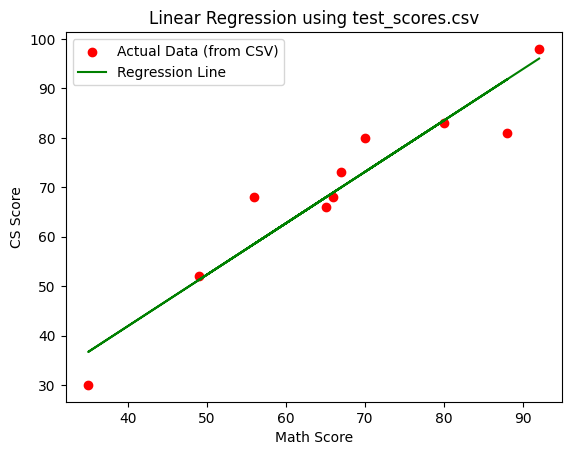

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV file
data = pd.read_csv("test_scores.csv")

# Use CSV data
x = np.array(data['math'])
y = np.array(data['cs'])

print("X values (from file):", x)
print("Y values (from file):", y)

# Gradient Descent Function
def gradient_descent(x, y):
    m = b = 0
    iterations = 10000
    n = len(x)
    learning_rate = 0.0001   # suitable for test score values

    for i in range(iterations):
        y_pred = m * x + b
        cost = (1/n) * np.sum((y - y_pred)**2)

        md = -(2/n) * np.sum(x * (y - y_pred))
        bd = -(2/n) * np.sum(y - y_pred)

        m -= learning_rate * md
        b -= learning_rate * bd

        if i % 1000 == 0:
            print(f"iteration {i}, m={m}, b={b}, cost={cost}")

    return m, b

# Train model using FILE data
m, b = gradient_descent(x, y)

print("\nFinal Model:")
print("Slope (m):", m)
print("Intercept (b):", b)

# Prediction example
math_score = 90
predicted_cs = m * math_score + b
print(f"\nPredicted CS score for Math = {math_score} is {predicted_cs}")

# Plot
plt.scatter(x, y, color='red', label='Actual Data (from CSV)')
plt.plot(x, m*x + b, color='green', label='Regression Line')
plt.xlabel("Math Score")
plt.ylabel("CS Score")
plt.title("Linear Regression using test_scores.csv")
plt.legend()
plt.show()